# Text Analysis EDA
Phân tích chi tiết về text trong dataset fake news tiếng Việt

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [8]:
# Load data
df = pd.read_csv('../../data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nInfo:")
print(df.info())
print(f"\nFirst row:")
print(df.head(1))

Dataset shape: (4736, 26)

Column names: ['id', 'user_name', 'timestamp_post', 'post_message', 'label', 'num_char', 'num_emoji', 'num_url', 'num_hashtag', 'num_post', 'num_real', 'num_fake', 'post_ratio', 'num_like', 'num_cmt', 'num_share', 'pixel', 'image', 'num_image', 'hour', 'weekday', 'day', 'month', 'year', 'time', 'min']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4736 entries, 0 to 4735
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4736 non-null   int64  
 1   user_name       4736 non-null   object 
 2   timestamp_post  4736 non-null   int64  
 3   post_message    4736 non-null   object 
 4   label           4736 non-null   int64  
 5   num_char        4736 non-null   int64  
 6   num_emoji       4736 non-null   int64  
 7   num_url         4736 non-null   int64  
 8   num_hashtag     4736 non-null   int64  
 9   num_post        4736 non-null   int64  
 10  num_real   

## 2. Text Length Analysis

In [10]:
# Extract text features
df['text_length'] = df['post_message'].str.len()
df['word_count'] = df['post_message'].str.split().str.len()

# Overall statistics
print("=" * 60)
print("TEXT LENGTH - OVERALL STATISTICS")
print("=" * 60)
print(f"\nCharacter count:")
print(df['text_length'].describe())

print(f"\nWord count:")
print(df['word_count'].describe())

TEXT LENGTH - OVERALL STATISTICS

Character count:
count     4736.000000
mean       770.985642
std       1478.991421
min          7.000000
25%        146.000000
50%        250.500000
75%        742.000000
max      28862.000000
Name: text_length, dtype: float64

Word count:
count    4736.000000
mean      142.611275
std       271.475201
min         3.000000
25%        27.000000
50%        47.000000
75%       136.000000
max      5038.000000
Name: word_count, dtype: float64


In [11]:
# By label
print("\n" + "=" * 60)
print("TEXT LENGTH - BY LABEL")
print("=" * 60)

by_label = df.groupby('label')[['text_length', 'word_count']].agg([
    'count', 'min', 'max', 'mean', 'median', 'std'
]).round(2)

print("\nText Length (characters):")
print(by_label['text_length'])

print("\nWord Count:")
print(by_label['word_count'])


TEXT LENGTH - BY LABEL

Text Length (characters):
       count  min    max    mean  median      std
label                                            
0       3929    7  28862  755.15   238.0  1489.06
1        807   31  14441  848.07   326.0  1427.35

Word Count:
       count  min   max    mean  median     std
label                                          
0       3929    3  5038  138.07    44.0  270.61
1        807    6  2905  164.70    64.0  274.74


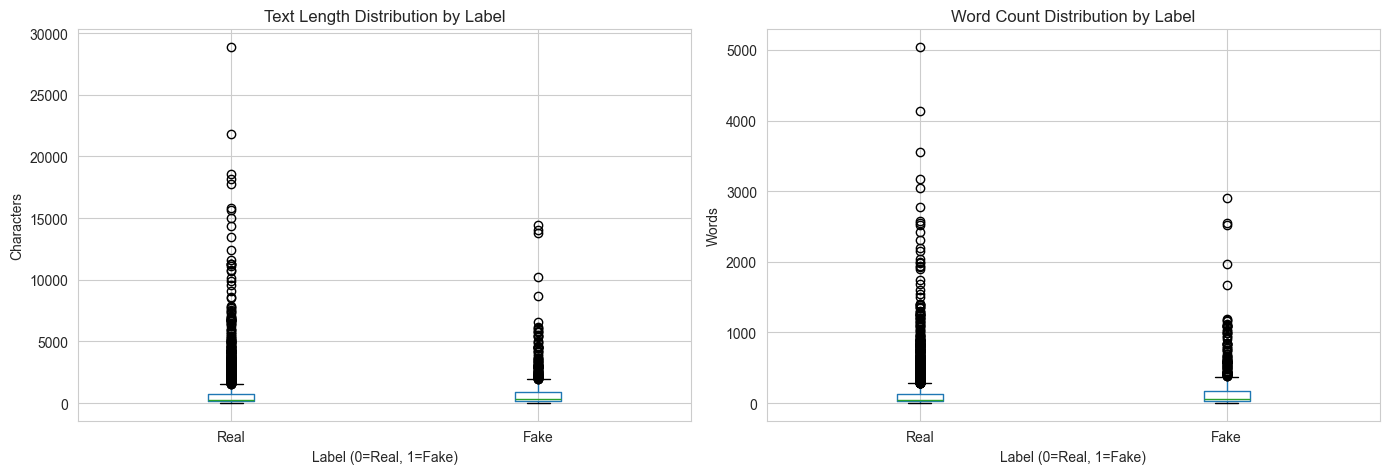

In [13]:
# Visualization: Box plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Text length box plot
df.boxplot(column='text_length', by='label', ax=ax[0])
ax[0].set_title('Text Length Distribution by Label')
ax[0].set_xlabel('Label (0=Real, 1=Fake)')
ax[0].set_ylabel('Characters')
ax[0].set_xticklabels(['Real', 'Fake'])

# Word count box plot
df.boxplot(column='word_count', by='label', ax=ax[1])
ax[1].set_title('Word Count Distribution by Label')
ax[1].set_xlabel('Label (0=Real, 1=Fake)')
ax[1].set_ylabel('Words')
ax[1].set_xticklabels(['Real', 'Fake'])

plt.suptitle('')
plt.tight_layout()
plt.show()

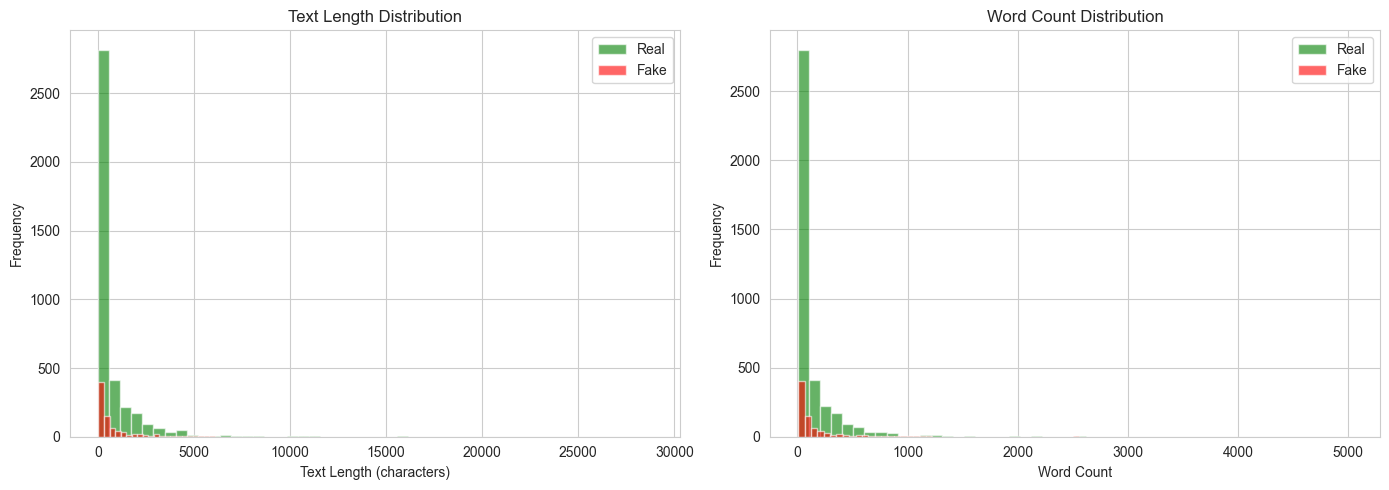

In [15]:
# Histogram
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Text length histogram
real_lengths = df[df['label'] == 0]['text_length']
fake_lengths = df[df['label'] == 1]['text_length']

ax[0].hist(real_lengths, bins=50, alpha=0.6, label='Real', color='green')
ax[0].hist(fake_lengths, bins=50, alpha=0.6, label='Fake', color='red')
ax[0].set_xlabel('Text Length (characters)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Text Length Distribution')
ax[0].legend()

# Word count histogram
real_words = df[df['label'] == 0]['word_count']
fake_words = df[df['label'] == 1]['word_count']

ax[1].hist(real_words, bins=50, alpha=0.6, label='Real', color='green')
ax[1].hist(fake_words, bins=50, alpha=0.6, label='Fake', color='red')
ax[1].set_xlabel('Word Count')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Word Count Distribution')
ax[1].legend()

plt.tight_layout()
plt.show()

## 3. BERT Compatibility Check

In [19]:
import pandas as pd
from transformers import AutoTokenizer

# 1. Load tokenizer (chính xác)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# 2. Function xử lý NaN
def count_actual_tokens(text):
    if pd.isna(text) or text == '':
        return 0
    try:
        tokens = tokenizer.encode(text)
        return len(tokens)
    except Exception as e:
        print(f"Error tokenizing: {e}")
        return 0

df['actual_tokens'] = df['post_message'].apply(count_actual_tokens)

# 4. Rest of code
max_bert_tokens = 512
over_limit = (df['actual_tokens'] > max_bert_tokens).sum()

print("=" * 60)
print("BERT COMPATIBILITY")
print("=" * 60)
print(f"\nMax BERT tokens: {max_bert_tokens}")
print(f"Actual max tokens in data: {df['actual_tokens'].max():.0f}")
print(f"Actual avg tokens in data: {df['actual_tokens'].mean():.0f}")
print(f"Texts exceeding {max_bert_tokens} tokens: {over_limit} ({over_limit/len(df)*100:.2f}%)")

if over_limit > 0:
    print(f"\n⚠️ ACTION: Will truncate to {max_bert_tokens} tokens during tokenization")
else:
    print(f"\n✅ All texts within BERT limit!")

BERT COMPATIBILITY

Max BERT tokens: 512
Actual max tokens in data: 5284
Actual avg tokens in data: 167
Texts exceeding 512 tokens: 379 (8.00%)

⚠️ ACTION: Will truncate to 512 tokens during tokenization


## 4. Text Quality Check

In [21]:
print("=" * 60)
print("TEXT QUALITY CHECKS")
print("=" * 60)

# Missing values
missing = df['post_message'].isnull().sum()
print(f"\nMissing textsxyz: {missing}")

# Empty texts
empty = (df['post_message'].str.strip() == '').sum()
print(f"Empty texts: {empty}")

# Duplicates
duplicates = df.duplicated(subset=['post_message']).sum()
print(f"Duplicate texts: {duplicates}")

if duplicates > 0:
    print(f"\n⚠️ ACTION: Duplicates found! Must remove before train/test split")

TEXT QUALITY CHECKS

Missing textsxyz: 0
Empty texts: 0
Duplicate texts: 0


## 5. Special Characters & Preprocessing Signals

In [23]:
print("=" * 60)
print("PREPROCESSING SIGNALS")
print("=" * 60)

# URLs
df['has_url'] = df['post_message'].str.contains(r'http\S+|www\S+', regex=True)
url_count = df['has_url'].sum()
print(f"\nTexts with URLs: {url_count} ({url_count/len(df)*100:.2f}%)")
# By label
print(f"  Real: {df[df['label']==0]['has_url'].sum()} ({df[df['label']==0]['has_url'].sum()/len(df[df['label']==0])*100:.2f}%)")
print(f"  Fake: {df[df['label']==1]['has_url'].sum()} ({df[df['label']==1]['has_url'].sum()/len(df[df['label']==1])*100:.2f}%)")

# Underscores (từ ghép)
df['underscore_count'] = df['post_message'].str.count('_')
underscore_texts = (df['underscore_count'] > 0).sum()
print(f"\nTexts with underscores: {underscore_texts} ({underscore_texts/len(df)*100:.2f}%)")
print(f"  Avg underscores per text: {df['underscore_count'].mean():.2f}")

# HTML tags
df['has_html'] = df['post_message'].str.contains(r'<[^>]+>', regex=True)
html_count = df['has_html'].sum()
print(f"\nTexts with HTML tags: {html_count}")

# Special characters (excluding Vietnamese diacritics)
def count_special_chars(text):
    return len(re.findall(r'[^\w\s\u0100-\u017f\u0180-\u024f]', text, flags=re.UNICODE))

df['special_char_count'] = df['post_message'].apply(count_special_chars)
print(f"\nSpecial characters statistics:")
print(df['special_char_count'].describe())

PREPROCESSING SIGNALS

Texts with URLs: 6 (0.13%)
  Real: 6 (0.15%)
  Fake: 0 (0.00%)

Texts with underscores: 4698 (99.20%)
  Avg underscores per text: 42.21

Texts with HTML tags: 1433

Special characters statistics:
count    4736.000000
mean       25.723395
std        47.389023
min         0.000000
25%         4.000000
50%         9.000000
75%        25.000000
max       764.000000
Name: special_char_count, dtype: float64


## 6. Vietnamese Language Check

In [34]:
# Check for Vietnamese characters
def has_vietnamese(text):
    return bool(re.search(r'[\u0100-\u017f\u0180-\u024f]', text))

df['has_vietnamese'] = df['post_message'].apply(has_vietnamese)

viet_count = df['has_vietnamese'].sum()
non_viet_count = len(df) - viet_count

print("=" * 60)
print("VIETNAMESE LANGUAGE CHECK")
print("=" * 60)
print(f"\nTexts with Vietnamese chars: {viet_count} ({viet_count/len(df)*100:.2f}%)")
print(f"Non-Vietnamese texts: {non_viet_count}")

if non_viet_count > 0:
    print(f"\n⚠️ Non-Vietnamese texts sample:")
    print(df[~df['has_vietnamese']]['post_message'].head(3).values)

VIETNAMESE LANGUAGE CHECK

Texts with Vietnamese chars: 4637 (97.91%)
Non-Vietnamese texts: 99

⚠️ Non-Vietnamese texts sample:
['< url >'
 'Cấm vô thời_hạn tất_cả các chuyến bay từ Việt_Nam qua Hàn_Quốc vì dịch Corona tại Hàn bùng_phát .'
 'Viettel miễn_phí nhiều giải_pháp làm_việc trực_tuyến tại nhà cho doanh_nghiệp']


## 7. Statistical Tests

In [38]:
from scipy.stats import ttest_ind, mannwhitneyu

print("=" * 60)
print("STATISTICAL TESTS (Real vs Fake)")
print("=" * 60)

real_lengths = df[df['label'] == 0]['text_length']
fake_lengths = df[df['label'] == 1]['text_length']

# T-test
t_stat, p_value = ttest_ind(real_lengths, fake_lengths)
print(f"\nT-test (text length):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
if p_value < 0.05:
    print(f"  ✅ Significant difference between Real & Fake!")
else:
    print(f"  ❌ No significant difference")

# Mann-Whitney U test
u_stat, p_value = mannwhitneyu(real_lengths, fake_lengths)
print(f"\nMann-Whitney U test (non-parametric):")
print(f"  U-statistic: {u_stat:.4f}")
print(f"  p-value: {p_value:.4e}")

STATISTICAL TESTS (Real vs Fake)

T-test (text length):
  t-statistic: -1.6258
  p-value: 1.0406e-01
  ❌ No significant difference

Mann-Whitney U test (non-parametric):
  U-statistic: 1414624.5000
  p-value: 1.3949e-06


## 8. Summary Report

In [39]:
import json

# Create summary
summary = {
    "total_samples": len(df),
    "text_quality": {
        "missing_values": int(df['post_message'].isnull().sum()),
        "empty_texts": int((df['post_message'].str.strip() == '').sum()),
        "duplicate_texts": int(df.duplicated(subset=['post_message']).sum())
    },
    "text_length": {
        "min": int(df['text_length'].min()),
        "max": int(df['text_length'].max()),
        "mean": round(df['text_length'].mean(), 2),
        "median": int(df['text_length'].median()),
        "std": round(df['text_length'].std(), 2)
    },
    "by_label": {
        "real": {
            "count": int((df['label'] == 0).sum()),
            "avg_length": round(df[df['label']==0]['text_length'].mean(), 2),
            "avg_words": round(df[df['label']==0]['word_count'].mean(), 2)
        },
        "fake": {
            "count": int((df['label'] == 1).sum()),
            "avg_length": round(df[df['label']==1]['text_length'].mean(), 2),
            "avg_words": round(df[df['label']==1]['word_count'].mean(), 2)
        }
    },
    "preprocessing_needed": {
        "texts_with_urls": int(df['has_url'].sum()),
        "texts_with_underscores": int((df['underscore_count'] > 0).sum()),
        "texts_with_html": int(df['has_html'].sum())
    },
    "bert_compatibility": {
        "max_estimated_tokens": int(df['estimated_tokens'].max()),
        "avg_estimated_tokens": round(df['estimated_tokens'].mean(), 0),
        "texts_exceeding_512_tokens": int((df['estimated_tokens'] > 512).sum())
    }
}

print("\n" + "=" * 60)
print("TEXT ANALYSIS SUMMARY")
print("=" * 60)
print(json.dumps(summary, indent=2, ensure_ascii=False))


TEXT ANALYSIS SUMMARY
{
  "total_samples": 4736,
  "text_quality": {
    "missing_values": 0,
    "empty_texts": 0,
    "duplicate_texts": 0
  },
  "text_length": {
    "min": 7,
    "max": 28862,
    "mean": 770.99,
    "median": 250,
    "std": 1478.99
  },
  "by_label": {
    "real": {
      "count": 3929,
      "avg_length": 755.15,
      "avg_words": 138.07
    },
    "fake": {
      "count": 807,
      "avg_length": 848.07,
      "avg_words": 164.7
    }
  },
  "preprocessing_needed": {
    "texts_with_urls": 6,
    "texts_with_underscores": 4698,
    "texts_with_html": 1433
  },
  "bert_compatibility": {
    "max_estimated_tokens": 7215,
    "avg_estimated_tokens": 193.0,
    "texts_exceeding_512_tokens": 461
  }
}


## 9. Key Findings & Decisions

In [40]:
print("\n" + "=" * 60)
print("KEY FINDINGS & PREPROCESSING DECISIONS")
print("=" * 60)

print("\nACTIONS TO TAKE:")
print("-" * 60)

if df.duplicated(subset=['post_message']).sum() > 0:
    print(f"1. Remove {df.duplicated(subset=['post_message']).sum()} duplicate texts")
else:
    print(f"1. No duplicates to remove")

if df['has_url'].sum() > 0:
    print(f"2. Remove URLs from {df['has_url'].sum()} texts")

if (df['underscore_count'] > 0).sum() > 0:
    print(f"3. Replace underscores with spaces in {(df['underscore_count'] > 0).sum()} texts")

if df['has_html'].sum() > 0:
    print(f"4. Remove HTML tags from {df['has_html'].sum()} texts")

print(f"5. Keep Vietnamese diacritics (BERT handles well)")
print(f"6. Use stratified train/test split (preserve {(df['label']==0).sum()/len(df)*100:.1f}%-{(df['label']==1).sum()/len(df)*100:.1f}% ratio)")

print("\n" + "=" * 60)


KEY FINDINGS & PREPROCESSING DECISIONS

ACTIONS TO TAKE:
------------------------------------------------------------
1. No duplicates to remove
2. Remove URLs from 6 texts
3. Replace underscores with spaces in 4698 texts
4. Remove HTML tags from 1433 texts
5. Keep Vietnamese diacritics (BERT handles well)
6. Use stratified train/test split (preserve 83.0%-17.0% ratio)

